#### The notebook is for diff types of classification trees.

In [108]:
library(rsample)     # data splitting 
library(dplyr)       # data wrangling
library(rpart)       # performing regression trees
library(rpart.plot)  # plotting regression trees
library(ipred)       # bagging
library(caret)       # bagging
library(smotefamily)
library(janitor) 
library(readr)
library(tidyverse)
library(caret)
library(xgboost)

The following code block is for loading the data and splitting it into training and testing sets. This is done with createDataPartition to ensure approx same distribution and we assume a place with outbreak has to have more than 2 cases.

In [109]:
set.seed(100)

df <- read_csv("data/merged_data.csv") |> clean_names() 

# outbreak >=2 is with outbreak, vice versa.
# set param for def 
df$outbreak <- as.integer(df$outbreak >= 2)

# split the data with stratified sampling
strata <- ifelse(df$outbreak > 0, "nonzero", "zero")
index <- createDataPartition(strata, p = 0.75, list = FALSE)
train <- df[index,]
test <- df[-index,]
head(train)

Rows: 254 Columns: 404
-- Column specification --------------------------------------------------------
Delimiter: ","
chr   (1): County
dbl (380): cve, outbreak, enrollment, PHR, pct_hispanic, pct_black, pct_whit...
lgl  (23): median_income, Advised to Cut Down Salt - Do not use salt, Diabet...

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


county,cve,outbreak,enrollment,phr,pct_hispanic,pct_black,pct_white,pct_poverty,pct_uninsured,...,up_to_date_cervical_cancer_s_no,up_to_date_cervical_cancer_s_yes,up_to_date_cervical_cancer_s_2_no,up_to_date_cervical_cancer_s_2_yes,v_col_5_yrs_50_75_ia_no,v_col_5_yrs_50_75_ia_yes,v_col_5_yrs_age_50_75_no,v_col_5_yrs_age_50_75_yes,virtual_colonoscopy_no,virtual_colonoscopy_yes
<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Anderson,2.54,0,7808,4,19.6,18.6,58.3,13.5,18.5,...,NA,NA,NA,NA,92.8,NA,92.8,NA,72.4,NA
Angelina,2.50,0,15649,5,23.5,12.1,63.4,11.5,17.7,...,36.9,63.1,36.8,63.2,92.2,NA,92.3,NA,65.5,34.5
Armstrong,5.24,0,297,1,12.0,0.6,89.9,6.0,4.2,...,39.9,60.1,40.0,60.0,96.9,NA,96.9,NA,76.0,NA
Austin,3.55,0,6290,6,27.8,7.9,66.6,10.6,16.7,...,39.2,60.8,39.1,60.9,97.0,NA,97.0,NA,74.3,25.7
Bailey,0.80,1,1330,1,66.0,0.9,71.3,7.4,28.6,...,39.9,60.1,40.0,60.0,96.9,NA,96.9,NA,76.0,NA
Bandera,3.78,0,2461,8,21.0,1.2,77.2,8.5,13.3,...,28.4,71.6,28.3,71.7,96.4,NA,96.3,NA,80.6,19.4


SMOTE function only takes in numeric data and unfortunately removing all NAs by row will remove all the counties. This code block is for pleasing SMOTE to work. We first remove county col as it is the only one with str, and then we remove all cols containing any flavor of NAs.

In [110]:
train <- train[, colSums(is.na(train)) == 0]
train <- train[, !names(train) %in% c("county")]

This code block is for creating artificial data for training using SMOTE method (fundamentally introducing noise) and balancing between the two class.

In [111]:
set.seed(42)
# K for controlling the neighborhood, dup_size for ratio to achieve
smote_output <- SMOTE(
  X      = train[, names(train) != "outbreak"],
  target = train$outbreak,
  K      = 5, 
  dup_size = 0 
)

train_balanced <- smote_output$data
# SMOTE put target data in "class" col and rename it
names(train_balanced)[names(train_balanced) == "class"] <- "outbreak"
train_balanced$outbreak <- as.factor(train_balanced$outbreak)
cat("\nClass balance after SMOTE:\n")
print(table(train_balanced$outbreak))

# mirror on test set
test <- test[, colSums(is.na(test)) == 0]
test <- test[, !names(test) %in% c("county")]
test$outbreak <- as.factor(test$outbreak)


Class balance after SMOTE:

  0   1 
174 162 


The analysis is for untuned model. The code block is for decision tree, it is almost without tuning except for the cp parameter.

In [112]:
# set decision tree
dtree_model <- rpart(outbreak ~ ., data = train_balanced, method = "class")

# eval performance s
pred <- predict(dtree_model, newdata = train, type = "class")

evaluation_table <- table(Actual = train$outbreak, Predicted = pred)
evaluation_table

# 2. View the complexity parameter table
printcp(dtree_model)

# 3. Find the cp value with the minimum xerror
opt_cp <- dtree_model$cptable[which.min(dtree_model$cptable[,"xerror"]), "CP"]

# 4. Prune the tree using the optimized CP
pruned_dtree_model <- prune(dtree_model, cp = opt_cp)

pred <- predict(pruned_dtree_model, newdata = train, type = "class")

dtree_table <- table(Actual = train$outbreak, Predicted = pred)
dtree_table

      Predicted
Actual   0   1
     0 162  12
     1   3  15


Classification tree:
rpart(formula = outbreak ~ ., data = train_balanced, method = "class")

Variables actually used in tree construction:
[1] current_e_cig_user_yes cve                    ever_had_hiv_test_yes 
[4] pct_college            pct_hispanic           phr                   

Root node error: 162/336 = 0.48214

n= 336 

        CP nsplit rel error  xerror     xstd
1 0.660494      0   1.00000 1.00000 0.056539
2 0.092593      1   0.33951 0.33951 0.041865
3 0.033951      2   0.24691 0.29630 0.039594
4 0.030864      4   0.17901 0.28395 0.038895
5 0.021605      5   0.14815 0.27778 0.038536
6 0.010000      7   0.10494 0.24691 0.036643


      Predicted
Actual   0   1
     0 162  12
     1   3  15

This code is for random forest without param tuning

In [113]:
library(randomForest)

# TODO we also need mtry
c = 0.4 #how many trees need to agree

rforest_model <- randomForest(outbreak ~ ., data = train_balanced, ntree = 500, importance = TRUE)

pred <- predict(rforest_model, newdata = train, type = "class", cutoff=c(c, 1-c))
rforest_table <- table(Actual = train$outbreak, Predicted = pred)
rforest_table

# Mean decreased accuracy basically says if a variable is omitted, how much does the mean accurary decrease by
# Mean decreased gini measures how often the varaible is used to slip data into classes 
#importance(model)



      Predicted
Actual   0   1
     0 159  15
     1   4  14

This code block is for XGBoost without param tuning which is a gradient based method. We use it than usual boosting because we have large amount of covariates and it is more efficient.

      Predicted
Actual   0   1
     0 174   0
     1   0  18

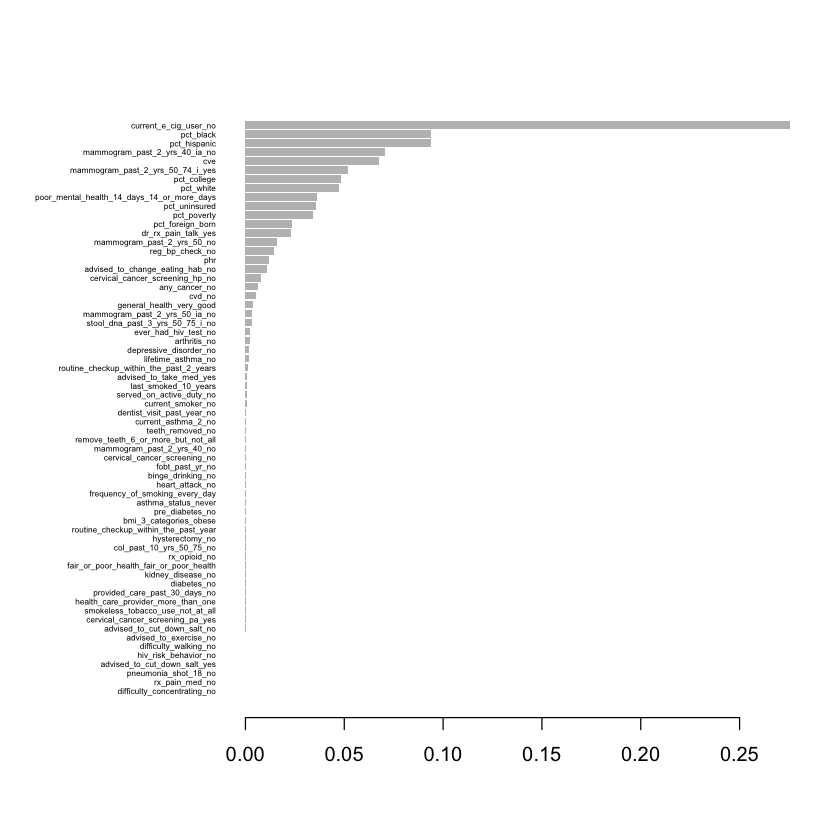

In [114]:
# boos: The algorithm draws a bootstrap sample of the training data in each iteration using the weights for each observation. 
# Misclassified or harder-to-predict samples receive higher weights, meaning they are 
# more likely to be selected for the next tree's training data

# mfinal: number of iterations

# TODO: add control bc it uses rpart each iteration
# Prepare matrices for xgb boost
X_train <- as.matrix(train_balanced[, names(train_balanced) != "outbreak"])
y_train <- as.numeric(as.character(train_balanced$outbreak))

X_test  <- as.matrix(train[, names(train) != "outbreak"])
y_test  <- as.numeric(as.character(train$outbreak))

dtrain  <- xgb.DMatrix(data = X_train, label = y_train)
dtest   <- xgb.DMatrix(data = X_test,  label = y_test)

boost_model <- xgb.train(
  params = list(
    objective   = "multi:softmax",
    eval_metric = "mlogloss",
    num_class   = 2,
    max_depth   = 3,
    eta         = 0.1
  ),
  data    = dtrain,
  nrounds = 500
)

pred <- as.factor(predict(boost_model, dtest))

boost_table <- table(Actual = as.factor(y_test), Predicted = pred)
boost_table

# importance graph
importance_matrix <- xgb.importance(model = boost_model)
xgb.plot.importance(importance_matrix)

In [117]:
get_accuracy <- function(eval_table) {
  round(sum(diag(eval_table)) / sum(eval_table) * 100, 2)
}

results <- data.frame(
  Model    = c("Decision Tree (rpart)", "Random Forest", "XGBoost (softmax)"),
  Cutoff   = c("default", c, "default"),
  Accuracy = c(
    get_accuracy(dtree_table),
    get_accuracy(rforest_table),
    get_accuracy(boost_table)
  )
)

results$Best     <- ifelse(results$Accuracy == max(results$Accuracy), "<--", "")

print(results, row.names = FALSE)

                 Model  Cutoff Accuracy Best
 Decision Tree (rpart) default    92.19     
         Random Forest     0.4    90.10     
     XGBoost (softmax) default   100.00  <--


The following code block are set for auto select parameters for the tree model. We create a hypergrid with different values for the parameters and then we loop through all combinations to find the one lowest RMSE.

In [116]:
hyper_grid <- expand.grid(
  minsplit = seq(5, 20, 1),
  maxdepth = seq(8, 15, 1)
)

models <- list()

for (i in 1:nrow(hyper_grid)) {

  # get minsplit, maxdepth values at row i
  minsplit <- hyper_grid$minsplit[i]
  maxdepth <- hyper_grid$maxdepth[i]

  # train a model and store in the list
  models[[i]] <- rpart(
    formula = outbreak ~ .,
    data    = df,
    method  = "anova",
    control = list(minsplit = minsplit, maxdepth = maxdepth)
    )
}
get_cp <- function(x) {
  min    <- which.min(x$cptable[, "xerror"])
  cp <- x$cptable[min, "CP"] 
}

# function to get minimum error
get_min_error <- function(x) {
  min    <- which.min(x$cptable[, "xerror"])
  xerror <- x$cptable[min, "xerror"] 
}

hyper_grid %>%
  mutate(
    cp    = purrr::map_dbl(models, get_cp),
    error = purrr::map_dbl(models, get_min_error)
    ) %>%
  arrange(error) %>%
  top_n(-5, wt = error)

minsplit,maxdepth,cp,error
<dbl>,<dbl>,<dbl>,<dbl>
6,12,1,1.001832
17,12,1,1.002634
9,14,1,1.002719
17,11,1,1.002804
8,8,1,1.003363
